# Formative Assignment 1 — Mobile Network Traffic Forecasting

**Name:** vestine umukundwa

**Dataset:** Milan telecom (SMS / Call / Internet) Harvard Dataverse 

**Research question:** *How do different sequential models compare for one-step-ahead
mobile network traffic forecasting, and how does their performance vary across
geographical areas with different traffic characteristics?*

The notebook follows the four tasks in the brief:

1. Data handling & memory management
2. Exploratory analysis
3. Related work & model selection
4. Forecasting experiments 


## 1. Setup

Install the libraries, import them once, and load your Dataverse API token from a `.env`
file so the token is never written directly in the notebook.

In [2]:
import os
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import requests

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("Libraries loaded.")

Libraries loaded.


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv, dotenv_values, find_dotenv

# 1) Try to find a .env automatically (searches the current folder and its parents)
env_path = find_dotenv(usecwd=True)

# 2) If not found, check some common locations (add/edit your own path here)
if not env_path:
    candidates = [
        Path.cwd() / ".env",
        Path.home() / "OneDrive" / "Desktop" / "alu-machine_learning" / "Time-Series-Forecasting" / ".env",
        Path.home() / "Desktop" / "Time-Series-Forecasting" / ".env",
    ]
    env_path = next((str(p) for p in candidates if p.is_file()), "")

print("Current folder:", Path.cwd())
print(".env found at :", env_path if env_path else "NOT FOUND")

# Load it and show which variable names are inside (helps spot typos)
if env_path:
    load_dotenv(env_path)
    print("Variables in .env:", list(dotenv_values(env_path).keys()))

API_TOKEN = os.getenv("DATAVERSE_API_TOKEN")

# 3) Last resort: if the file cannot be found, uncomment and paste your token here.

SERVER  = "https://dataverse.harvard.edu"
DOI     = "doi:10.7910/DVN/EGZHFV"
headers = {"X-Dataverse-key": API_TOKEN}

print("Token loaded:", API_TOKEN is not None)
if env_path and API_TOKEN is None:
    print("The .env was found but has no DATAVERSE_API_TOKEN. "
          "Make sure it contains the data token")

Current folder: c:\Users\LENOVO\OneDrive\Desktop\alu-machine_learning\Time-Series-Forecasting
.env found at : c:\Users\LENOVO\OneDrive\Desktop\alu-machine_learning\Time-Series-Forecasting\.env
Variables in .env: ['DATAVERSE_API_TOKEN']
Token loaded: True


In [4]:
# Check if the API token and server connection work

url = f"{SERVER}/api/datasets/:persistentId/"

# Send a request to the Dataverse server
response = requests.get(
    url,
    params={"persistentId": DOI},
    headers=headers
)

# Print the response status (200 means success)
print("Status:", response.status_code)

Status: 200


## 1. — Data Handling and Memory Management

### 1a. Downloading the data (handling the required guestbook)

This dataset has a **required guestbook** (`guestbookID 96`), so a plain
`GET .../access/datafile/{id}` is refused. The correct steps are:

1. **POST** an (empty) guestbook response to `.../access/datafile/{id}` → returns a
   short-lived **signed URL**.
2. **GET** that signed URL → it redirects to storage and returns the real file.

The helper below does this, streams the file to disk in 1 MB chunks (memory-safe for the
~300 MB files), and **skips files already downloaded**.

In [5]:
# Get information about the dataset

url = f"{SERVER}/api/datasets/:persistentId/"

# Ask the  server for the dataset information
response = requests.get(
    url,
    params={"persistentId": DOI},
    headers=headers
)

# Change the response into a Python dictionary
dataset_info = response.json()

# Get the list of files in the dataset
files = dataset_info["data"]["latestVersion"]["files"]

# Print how many files are in the dataset
print("Total files:", len(files))

# Print the name of the first file
print("First file:", files[0]["dataFile"]["filename"])

Total files: 62
First file: sms-call-internet-mi-2013-11-01.txt


In [6]:
import os

DATA_FOLDER = "data"

# Download one file
def download_file(file_id, filename):
    os.makedirs(DATA_FOLDER, exist_ok=True)

    # Get the download link
    link = requests.post(
        f"{SERVER}/api/access/datafile/{file_id}",
        headers=headers,
        json={"guestbookResponse": {}}
    ).json()["data"]["signedUrl"]

    # Save the file
    r = requests.get(link)
    with open(f"{DATA_FOLDER}/{filename}", "wb") as f:
        f.write(r.content)

    return "Downloaded"

# Test with the first file
first = files[0]["dataFile"]
print(download_file(first["id"], first["filename"]), first["filename"])

Downloaded sms-call-internet-mi-2013-11-01.txt


In [7]:
import os
import time

# Folder where files will be saved
DATA_DIR = "data"

# Function to download a file
def download_file(file_id, filename):

    # Create the data folder if it does not exist
    os.makedirs(DATA_DIR, exist_ok=True)

    # Try downloading the file 3 times
    for i in range(3):
        try:
            # Get a fresh download link
            link = requests.post(
                f"{SERVER}/api/access/datafile/{file_id}",
                headers=headers,
                json={"guestbookResponse": {}}
            ).json()["data"]["signedUrl"]

            # Download the file
            r = requests.get(link)
            r.raise_for_status()

            # Save the file
            with open(f"{DATA_DIR}/{filename}", "wb") as f:
                f.write(r.content)

            return "Downloaded"

        except:
            # If download fails, wait and try again
            print(f"Try {i+1} failed. Retrying...")
            time.sleep(2)

    # If all 3 attempts fail
    return "Failed"

In [8]:
# Download all files in the dataset
failures = []

for i, f in enumerate(files, start=1):

    # Get the file information
    file = f["dataFile"]

    # Download the file
    status = download_file(file["id"], file["filename"])

    # Show the progress
    print(f"[{i}/{len(files)}] {status} -> {file['filename']}")

    # Save the name if the download failed
    if status == "Failed":
        failures.append(file["filename"])

# Show failed downloads
print("\nFailed files:", failures if failures else "None")

[1/62] Downloaded -> sms-call-internet-mi-2013-11-01.txt
[2/62] Downloaded -> sms-call-internet-mi-2013-11-02.txt
[3/62] Downloaded -> sms-call-internet-mi-2013-11-03.txt
[4/62] Downloaded -> sms-call-internet-mi-2013-11-04.txt
[5/62] Downloaded -> sms-call-internet-mi-2013-11-05.txt
[6/62] Downloaded -> sms-call-internet-mi-2013-11-06.txt
[7/62] Downloaded -> sms-call-internet-mi-2013-11-07.txt
[8/62] Downloaded -> sms-call-internet-mi-2013-11-08.txt
[9/62] Downloaded -> sms-call-internet-mi-2013-11-09.txt
[10/62] Downloaded -> sms-call-internet-mi-2013-11-10.txt
[11/62] Downloaded -> sms-call-internet-mi-2013-11-11.txt
[12/62] Downloaded -> sms-call-internet-mi-2013-11-12.txt
[13/62] Downloaded -> sms-call-internet-mi-2013-11-13.txt
[14/62] Downloaded -> sms-call-internet-mi-2013-11-14.txt
[15/62] Downloaded -> sms-call-internet-mi-2013-11-15.txt
[16/62] Downloaded -> sms-call-internet-mi-2013-11-16.txt
[17/62] Downloaded -> sms-call-internet-mi-2013-11-17.txt
[18/62] Downloaded -> s

In [13]:
import pandas as pd

path = f"data/{files[0]['dataFile']['filename']}"   # a downloaded file

raw = pd.read_csv(path, sep="\t", header=None, nrows=5)

print("Columns:", list(raw.columns)) 
raw                                     # shows the first 5 rows with numbered columns

Columns: [0, 1, 2, 3, 4, 5, 6, 7]


,0,1,2,3,4,5,6,7
0,1,1383260400000,0,0.081,NaN,NaN,NaN,NaN
1,1,1383260400000,39,0.142,0.157,0.161,0.052,11.028
2,1,1383261000000,0,0.137,NaN,NaN,0.027,NaN
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026
4,1,1383261000000,39,0.278,0.120,0.189,0.134,11.101


> If you ran the *old* download code before, some files in `data/` may be tiny
> `{"status":"ERROR"...}` files. The `min_bytes` check above finds and re-downloads them.

### 1b. Measuring and reducing memory usage

We load one day **naively** (all 8 columns, default types), measure its memory, then load
it **optimised** (smaller numeric types) and measure again. Loading only the columns we
actually need (`usecols`) saves even more.

In [14]:
# Names of the 8 columns in the files
COLUMNS = [
    "SquareID", "TimeInterval", "CountryCode",
    "SMS_in", "SMS_out", "Call_in", "Call_out", "Internet"
]

# Find the first .txt file in the data folder
one_file = sorted(Path(DATA_DIR).glob("*.txt"))[0]

# Show which file we are using
print("Measuring on:", one_file.name)

Measuring on: sms-call-internet-mi-2013-11-01.txt


In [15]:
# Read the file normally
df = pd.read_csv(
    one_file,
    sep="\t",  #columns are separated by tabs
    header=None,
    names=COLUMNS
)

# Calculate how much memory the DataFrame uses
memory = df.memory_usage(deep=True).sum() / 1024**2

# Show the results
print(f"Rows: {len(df):,}")
print(f"Memory: {memory:.1f} MB")
print(df.dtypes)

Rows: 4,842,625
Memory: 295.6 MB
SquareID          int64
TimeInterval      int64
CountryCode       int64
SMS_in          float64
SMS_out         float64
Call_in         float64
Call_out        float64
Internet        float64
dtype: object


In [16]:
# Use smaller data types to save memory
dtypes = {
    "SquareID": "int16",
    "CountryCode": "int16",
    "TimeInterval": "int64",
    "SMS_in": "float32",
    "SMS_out": "float32",
    "Call_in": "float32",
    "Call_out": "float32",
    "Internet": "float32"
}

# Read the file using the smaller data types
df_opt = pd.read_csv(
    one_file,
    sep="\t",
    header=None,
    names=COLUMNS,
    dtype=dtypes
)

# Check the memory used
memory = df_opt.memory_usage(deep=True).sum() / 1024**2

print(f"Memory (optimised): {memory:.1f} MB")

Memory (optimised): 147.8 MB


In [24]:
# Calculate memory usage before and after optimisation
mem_before = df.memory_usage(deep=True).sum() / 1024**2
mem_after = df_opt.memory_usage(deep=True).sum() / 1024**2

# Calculate how much memory we saved
improvement = (mem_before - mem_after) / mem_before * 100

print(f"Memory reduced from {mem_before:.1f} MB "
      f"to {mem_after:.1f} MB ({improvement:.1f}% smaller)")


# Load only the 3 columns needed for Internet analysis
df_min = pd.read_csv(
    one_file,
    sep="\t",
    header=None,
    names=COLUMNS,
    usecols=["SquareID", "TimeInterval", "Internet"],
    dtype={
        "SquareID": "int16",
        "TimeInterval": "int64",
        "Internet": "float32"
    }
)

# Check memory used by the smaller DataFrame
memory = df_min.memory_usage(deep=True).sum() / 1024**2

print(f"Memory after reducing columns(3 columns): {memory:.1f} MB")

Memory reduced from 295.6 MB to 147.8 MB (50.0% smaller)
Memory after reducing columns(3 columns): 64.7 MB


In [25]:
print("Rows:", len(df))
print(f"Memory before optimization: {mem_before:.2f} MB")
print(f"Memory after optimization: {mem_after:.2f} MB")
print(f"Memory reduction: {improvement:.1f}%")

Rows: 4842625
Memory before optimization: 295.57 MB
Memory after optimization: 147.79 MB
Memory reduction: 50.0%


### Discussion 1

The unoptimised one-day DataFrame contains 4,842,625 rows and uses 295.6 MB. Replacing the default `int64` and `float64` columns with suitable `int16` and `float32` types reduces memory to 147.8 MB, a 50.0% reduction. Loading only `SquareID`, `TimeInterval`, and `Internet` reduces the example further to 64.7 MB.

The main techniques are selecting smaller dtypes, using `usecols` to avoid reading irrelevant variables, and processing files one at a time instead of reading all 62 daily files at the same time. These 2 approach makes the approximately 19.4 GB dataset practical on a normal computer. 

## 2. Exploratory Analysis

We study the **Internet** column only. Every function below reads the files **one at a
time** and keeps only what it needs, so memory stays small.

**Important:** each row is one *country code* for a (square, time). To get the traffic of
an *area* we sum the Internet value across country codes for each (square, time).

### 2.1 Distribution of total Internet traffic across areas

For each of the 10,000 areas, sum its Internet activity over the whole period, then look
at how those totals are distributed.

In [26]:
def total_internet_per_square(data_dir=DATA_DIR):

    # Store Internet totals for each area
    totals = None

    # Read one file at a time to save memory
    for path in sorted(Path(data_dir).glob("*.txt")):

        # Load only the columns we need
        data = pd.read_csv(
            path,
            sep="\t",
            header=None,
            names=COLUMNS,
            usecols=["SquareID", "Internet"],
            dtype={"SquareID": "int16", "Internet": "float32"}
        )

        # Add Internet usage for each area
        daily_total = data.groupby("SquareID")["Internet"].sum()

        # Combine with totals from previous files
        totals = daily_total if totals is None else totals.add(
            daily_total, fill_value=0
        )

    # Sort areas from highest to lowest Internet usage
    return totals.sort_values(ascending=False)


# Calculate total Internet usage
totals = total_internet_per_square()

print("Number of areas:", len(totals))
print(totals.head())

Number of areas: 10000
SquareID
5161   12,740,060.000
5059   11,170,854.000
5259   10,485,778.000
5061    9,584,333.000
5258    8,707,441.000
Name: Internet, dtype: float32


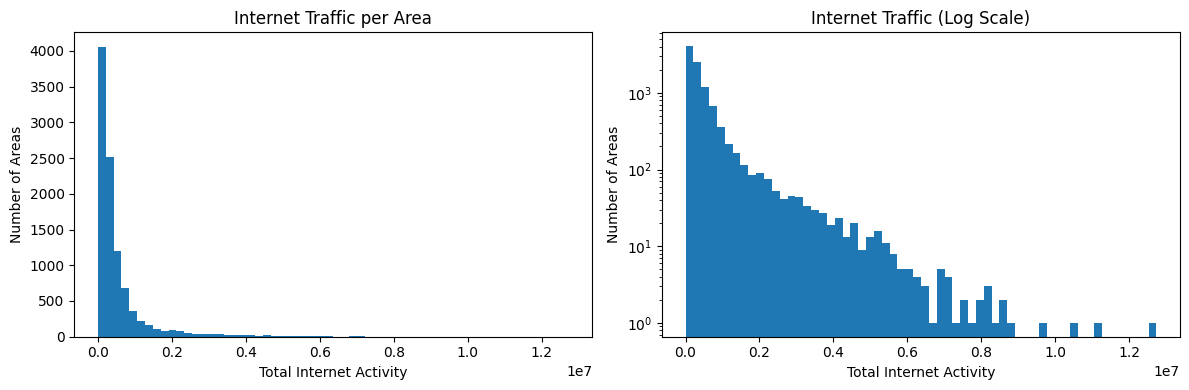

In [27]:
# Create two charts
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Normal histogram
ax[0].hist(totals.values, bins=60)
ax[0].set_title("Internet Traffic per Area")
ax[0].set_xlabel("Total Internet Activity")
ax[0].set_ylabel("Number of Areas")

# Histogram with log scale
ax[1].hist(totals.values, bins=60)
ax[1].set_yscale("log")
ax[1].set_title("Internet Traffic (Log Scale)")
ax[1].set_xlabel("Total Internet Activity")
ax[1].set_ylabel("Number of Areas")

# Display the charts
plt.tight_layout()
plt.show()

### Discussion 2.1

The distribution on the right most areas have  low total Internet activity, while a small number of areas contribute much larger totals. The ordinary histogram compresses together the low traffic areas because of those high traffic observations; the logarithmic y-axis makes the bulk of the distribution easier to inspect and observe. is clear to see how there is low internet activity in most areas and high in few areas


### 2.2 Top 3 areas and time series for five areas (first two weeks)

Take the three highest-traffic areas plus Square 4159 and Square 4556, and plot the first
two weeks of their Internet time series.

In [28]:
# Get the 3 areas with the highest Internet usage
top3 = list(totals.head(3).index)

print("Top 3 areas by by total Internet traffic:", top3)

# Add two specific areas for comparison
squares_to_plot = top3 + [4159, 4556]

print("Areas to plot:", squares_to_plot)

Top 3 areas by by total Internet traffic: [5161, 5059, 5259]
Areas to plot: [5161, 5059, 5259, 4159, 4556]


In [29]:
def build_series(squares, data_dir=DATA_DIR, start=None, end=None):

    # Store data from all files
    parts = []

    # Read one file at a time
    for path in sorted(Path(data_dir).glob("*.txt")):

        # Load only the columns we need
        data = pd.read_csv(
            path,
            sep="\t",
            header=None,
            names=COLUMNS,
            usecols=["SquareID", "TimeInterval", "Internet"],
            dtype={
                "SquareID": "int16",
                "TimeInterval": "int64",
                "Internet": "float32"
            }
        )

        # Keep only the selected areas
        data = data[data["SquareID"].isin(squares)]

        if data.empty:
            continue

        # Add Internet usage for each area and time
        data = data.groupby(
            ["SquareID", "TimeInterval"]
        )["Internet"].sum().reset_index()

        parts.append(data)

    # Combine all files
    data = pd.concat(parts, ignore_index=True)

    # Convert time from milliseconds to date/time
    data["time"] = pd.to_datetime(data["TimeInterval"], unit="ms")

    # Put each area in its own column
    result = data.pivot_table(
        index="time",
        columns="SquareID",
        values="Internet"
    ).sort_index()

    # filter by date
    if start:
        result = result[result.index >= start]

    if end:
        result = result[result.index < end]

    return result

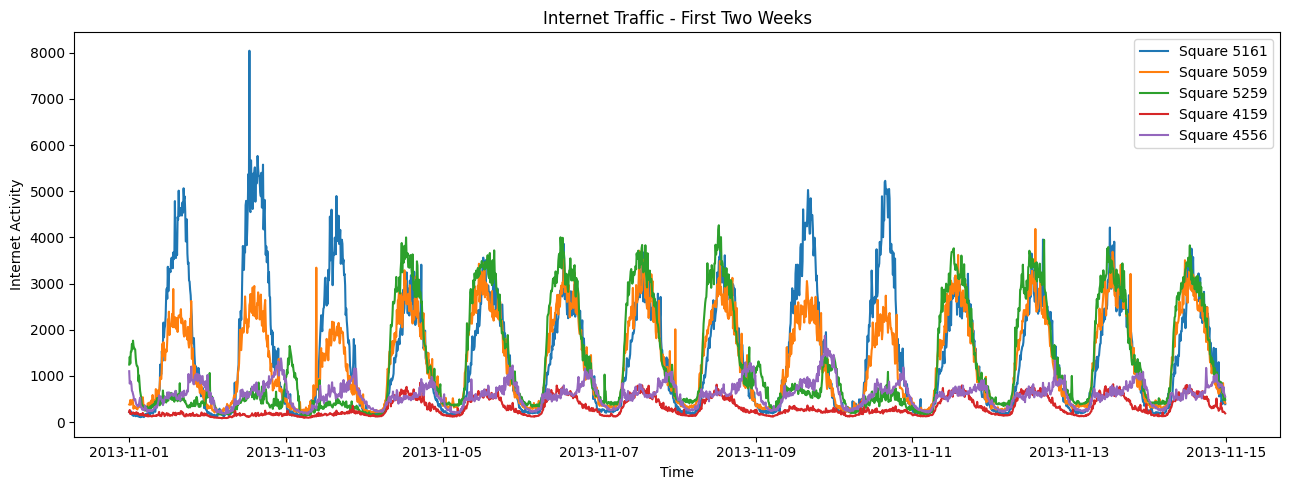

In [30]:
# Get Internet data for the first two weeks
two_weeks = build_series(
    squares_to_plot,
    start="2013-11-01",
    end="2013-11-15"
)

# Create the graph
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each selected area
for square in squares_to_plot:
    if square in two_weeks.columns:
        ax.plot(
            two_weeks.index,
            two_weeks[square],
            label=f"Square {square}"
        )

# Add labels and title
ax.set_title("Internet Traffic - First Two Weeks")
ax.set_xlabel("Time")
ax.set_ylabel("Internet Activity")
ax.legend()

# Show the graph
plt.tight_layout()
plt.show()

### Discussion — 2.2

All five areas show a repeated daily cycle  traffic rises during the active part of the day and falls to a low baseline overnight. The top three areas have much larger amplitudes than Squares 4159 and 4556, which confirms that their total traffic ranking reflects  higher internet activity. Square 5161 is especially higher with the largest visible spikes, while the lower-volume areas have smaller but still recognisable cycles.

### 2.3 Time-series analysis on the highest-traffic area

Use the highest-traffic area and look at its typical daily/weekly pattern
(seasonality) and  its autocorrelation and stationarity  

In [31]:
# Get the area with the highest Internet usage
top_square = top3[0]

print("Highest-traffic area:", top_square)

# Get all Internet data for this area
full = build_series([top_square])[top_square]

# Make the data every 10 minutes
# Fill small missing gaps
full = full.asfreq("10min").interpolate(limit_direction="both")

# Show the size and time range of the data
print("Series length:", len(full))
print("From:", full.index.min())
print("To:", full.index.max())

Highest-traffic area: 5161
Series length: 8928
From: 2013-10-31 23:00:00
To: 2014-01-01 22:50:00


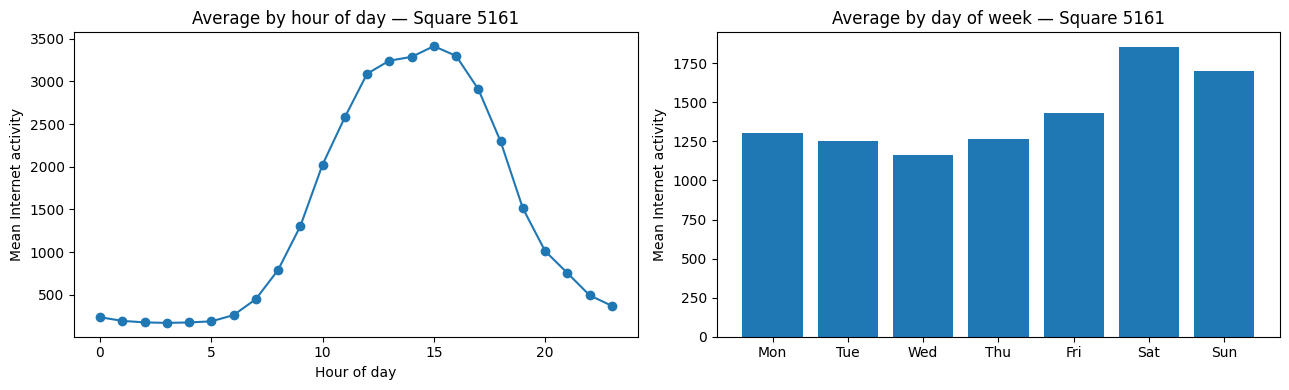

In [32]:
# (A) Average Internet activity by hour of day and by day of week
by_hour = full.groupby(full.index.hour).mean()
by_dow  = full.groupby(full.index.dayofweek).mean()      # 0 = Monday

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(by_hour.index, by_hour.values, marker="o")
ax[0].set_title(f"Average by hour of day — Square {top_square}")
ax[0].set_xlabel("Hour of day"); ax[0].set_ylabel("Mean Internet activity")

ax[1].bar(range(7), by_dow.values)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax[1].set_title(f"Average by day of week — Square {top_square}")
ax[1].set_ylabel("Mean Internet activity")
plt.tight_layout(); plt.show()

### Interpretation of the daily and weekly patterns

The hourly profile has a pronounced daily  activity is lowest overnight and rises in the morning toward daytime peaks before declining again. The day of week averages show that on the bar chart the days with most internet activities are Friday,saturday and sunday  and day with the lowest is wednesday .

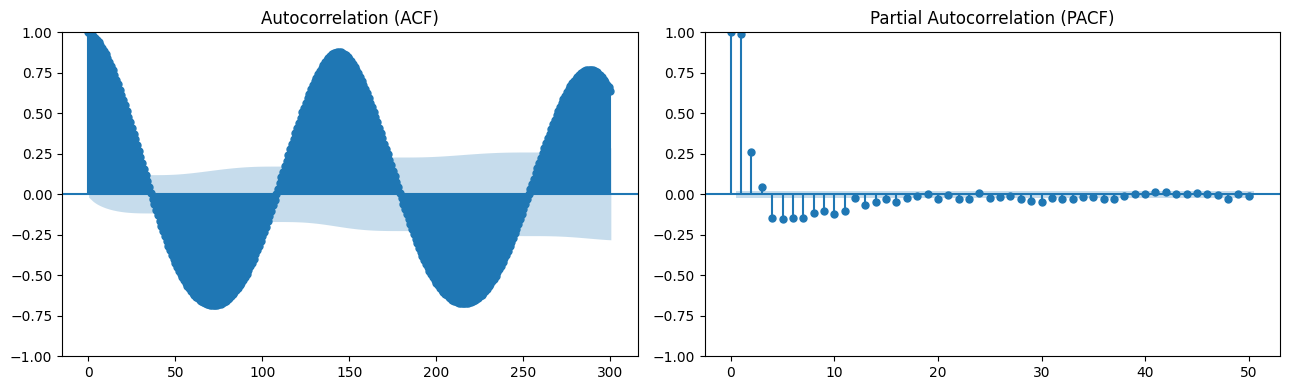

ADF statistic: -19.032
p-value: 0.0000
Stationary? True


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15652\3350153026.py:21: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, p_value = adfuller(full.values)[:2]


In [ ]:
# Check autocorrelation and stationarity

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Create ACF and PACF graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# ACF: checks how today's values relate to past values
plot_acf(full.values, lags=300, ax=ax[0])
ax[0].set_title("Autocorrelation (ACF)")

# PACF: checks the direct relationship with past values
plot_pacf(full.values, lags=50, ax=ax[1], method="ywm")
ax[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

# ADF test: checks if the series is stationary
adf_stat, p_value = adfuller(full.values)[:2]

print(f"ADF statistic: {adf_stat:.3f}")
print(f"p-value: {p_value:.4f}") # for checking stationarity
# stationary means the data's overall behavior stays consistent over time

# p-value < 0.05 means the series is stationary
print("Stationary?", p_value < 0.05)

### Interpretation of autocorrelation and stationarity

The ACF remains strongly positive at short lags and oscillates with a roughly daily period, showing that nearby observations and repeated daily structure contain substantial predictive information. The PACF has its strongest direct effects at the first few lags and then becomes much smaller, which supports a compact lag window rather than an unnecessarily long one.

The ADF statistic is -19.032 with a p-value with 0.00o, indicated the data is stationaly means data is consistent.

ACF → checks how strongly current Internet usage is related to previous values.
PACF → checks the direct effect of previous values.
ADF test → checks whether the time series is stationary.
p-value < 0.05 → usually means we consider the series stationary.

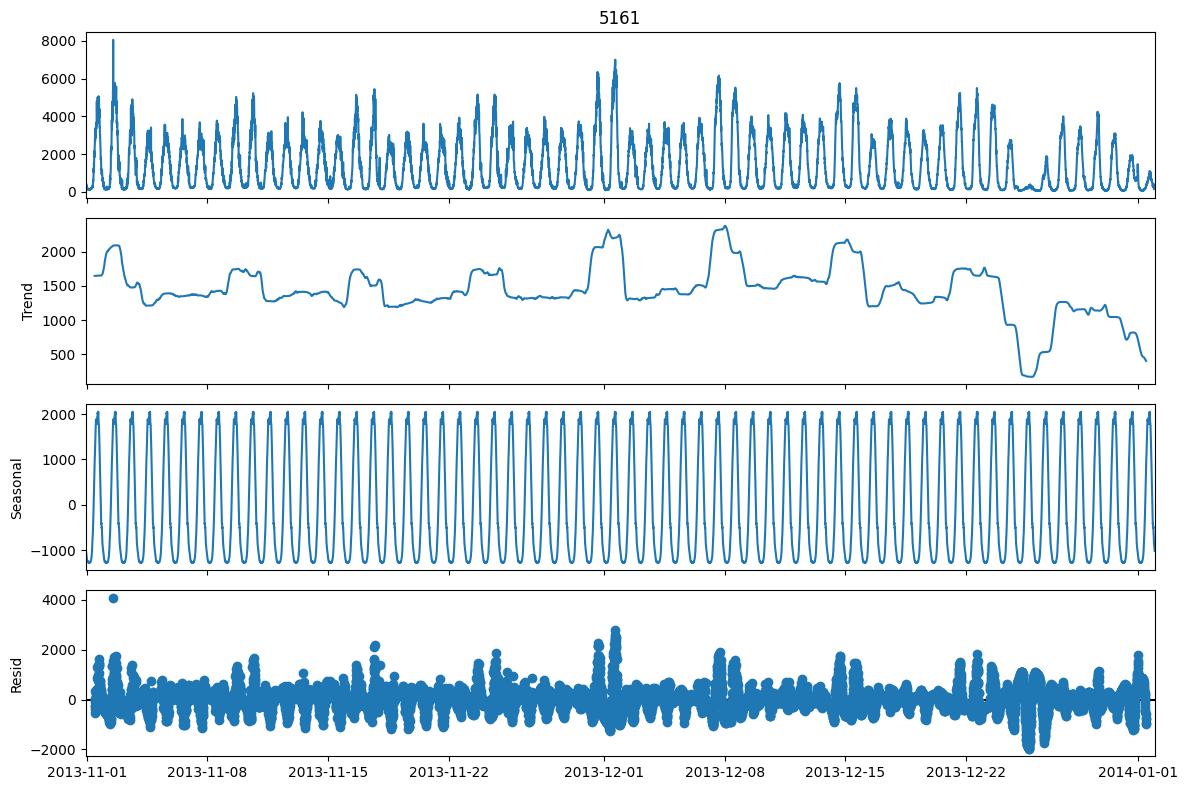

In [34]:
# Decompose the time series into trend, daily pattern, and residuals
from statsmodels.tsa.seasonal import seasonal_decompose

# 144 ten-minute periods = 1 day
result = seasonal_decompose(
    full,
    model="additive",
    period=144
)

# Show the decomposition
fig = result.plot()
fig.set_size_inches(12, 8)

plt.tight_layout()
plt.show()

### Interpretation of the decomposition

The decomposition separates the series into a slowly changing trend, a repeating seasonal component, and  noise. The seasonal component captures the regular daily traffic changes, while the residual component contains short lived spikes and irregular movements that are harder to predict. The trend becomes more pronounced near the end of December, and the accompanying increase in residual variation means forecasts for that period may be less reliable. The evaluation week of 16–22 December is therefore useful because it tests the models before the strongest late December change.

## 3. Task 3 — Related Work and Model Selection 

Mobile traffic is highly dependent on time: observations close together tend to be similar, and daily or weekly patterns repeat. Research on cellular traffic forecasting commonly compares statistical lag-based methods with neural networks, because traffic combines predictable temporal structure with non-linear bursts. The Task 2 ACF and plots show both properties in this dataset.

**Linear Regression on lagged values** is the transparent baseline. It uses the recent window to approximate an autoregressive model, trains quickly, and makes the effect of each lag easy to inspect. It is appropriate here because short-lag autocorrelation is strong, but it may miss non-linear peak behaviour and interactions between lags.

**The MLP** uses the same lag window but can learn non-linear relationships, such as different responses during rising and falling parts of the daily cycle. It is still fast enough for repeated experiments, but it treats the lag values as fixed input features rather than explicitly processing their order. It can also overfit when its hidden layers are made unnecessarily large.

**The LSTM** is designed for sequential data and can learn a recurrent memory representation of temporal dependencies. It is a natural candidate when long or complex dependencies matter, but it requires more training time and tuning than the two baselines. In this notebook the lag window is relatively short and the daily pattern is strong, so the experiment tests whether that extra flexibility produces a measurable benefit rather than assuming it will.

The three models therefore provide a useful progression: an interpretable linear baseline, a non-linear feed-forward model, and a recurrent sequential model. The persistence forecast is included as a simple reference point, not as one of the three selected learning models.

## 4. Task 4 — Forecasting Experiments

**aim:** one-step-ahead forecasting of Internet traffic for the **top-3 areas**,
evaluated on the week **16–22 December 2013**. We compare Linear Regression, MLP and LSTM,
with a persistence baseline for reference.

### 4.1 Input representation and shared settings

- **Input:** the last `N_LAGS` values (lagged data). **Target:** the next value.
- **Normalisation:** Min-Max, **fitted on the training part only** (no test leakage).
- **Splits:** training = before 9 Dec; **validation week** = 9-15 Dec 
- **test week** = 16-22 Dec (final, untouched during tuning).

In [ ]:
# Model settings
N_LAGS = 18              # Use the previous 18 values
MLP_HIDDEN = (64, 32)    # MLP hidden layers
LSTM_UNITS = 32           # Number of LSTM units (number or memory boxes for cell state and hidden state )
LSTM_EPOCHS = 10          # Training epochs

# Validation and test dates
VALID_START = "2013-12-09"
EVAL_START = "2013-12-16"
EVAL_END = "2013-12-23"   # 23 Dec is not included


# Convert time series into X and y
def make_supervised(values, n_lags):
    X, y = [], []

    for i in range(n_lags, len(values)):
        X.append(values[i-n_lags:i])  # Previous values
        y.append(values[i])           # Next value

    return np.array(X), np.array(y)


# Calculate MAPE
def mape(y_true, y_pred, threshold=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Ignore values close to zero
    mask = y_true > threshold

    if not mask.any():
        return np.nan

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


# Calculate model performance
def metrics_table(y_true, predictions):
    results = {}

    for name, pred in predictions.items():
        results[name] = {
            "MAE": mean_absolute_error(y_true, pred),
            "MAPE": mape(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred) ** 0.5
        }

    return pd.DataFrame(results).T[["MAE", "MAPE", "RMSE"]]


# Check if TensorFlow is available
try:
    from tensorflow import keras
    from tensorflow.keras import layers

    HAS_TF = True
    print("TensorFlow available.")

except Exception:
    HAS_TF = False
    print("TensorFlow NOT available - LSTM will be skipped.")

TensorFlow available.


### 4.2 Hyperparameter tuning 

We tune on the **validation week (9-15 Dec)** so the test week stays untouched. We change
**one thing at a time**, record the validation error in a table, and pick the best value.
This is the iterative process the brief asks for.

In [ ]:
# Train on data before the test period
# Then predict values inside the test period

def run_window(series, n_lags, build_and_predict, test_start, test_end):

    # Use only data before the test period for training
    train = series[series.index < test_start]

    # Scale the data using training data only
    scaler = MinMaxScaler()
    scaler.fit(train.values.reshape(-1, 1))

    # Scale the whole series
    scaled = scaler.transform(
        series.values.reshape(-1, 1)
    ).ravel()

    # Create lagged input data
    X, y = make_supervised(scaled, n_lags)

    # Match each X/y row with its time(making sure that we don't train lagged data without historical values)
    times = series.index[n_lags:]

    # Select the test period(checking the time step on each row of the series if it falls within the test_start and test_end)
    test = (times >= test_start) & (times < test_end)

    # Train the model and make predictions
    predictions = build_and_predict(
        X[~test],
        y[~test],
        X[test]
    )

    # Convert predictions back to the original scale
    y_true = scaler.inverse_transform(
        y[test].reshape(-1, 1)
    ).ravel()

    y_pred = scaler.inverse_transform(
        np.asarray(predictions).reshape(-1, 1)
    ).ravel()

    return y_true, y_pred, times[test]


# Use the highest-traffic area for tuning
tune_series = full

In [37]:
# Experiment A: Find the best number of lag values
# We use Linear Regression because it is fast

def lr_build(X_train, y_train, X_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model.predict(X_test)


results = []

# Try different numbers of previous values
for n in [6, 12, 18, 36, 72]:

    # Train and test using this number of lags
    y_true, y_pred, _ = run_window(
        tune_series,
        n,
        lr_build,
        VALID_START,
        EVAL_START
    )

    # Save the errors
    results.append({
        "N_LAGS": n,
        "val_MAE": mean_absolute_error(y_true, y_pred),
        "val_RMSE": mean_squared_error(y_true, y_pred) ** 0.5
    })


# Put results into a table
expA = pd.DataFrame(results).set_index("N_LAGS")

print("N_LAGS tuning results:")
display(expA)


# Choose the lag with the lowest MAE
N_LAGS = int(expA["val_MAE"].idxmin())

print("Chosen N_LAGS:", N_LAGS)

N_LAGS tuning results:


,val_MAE,val_RMSE
N_LAGS,,
6,110.076,164.687
12,107.642,158.623
18,107.768,158.271
36,109.010,157.144
72,107.723,156.861


Chosen N_LAGS: 12


In [38]:
# Experiment B: Find the best MLP hidden layers

results = []

# Try different MLP structures
for hidden in [(32,), (64, 32), (128, 64)]:

    def build_mlp(X_train, y_train, X_test, hidden=hidden):
        model = MLPRegressor(
            hidden_layer_sizes=hidden,
            max_iter=300,
            random_state=0,
            early_stopping=True
        )

        model.fit(X_train, y_train)
        return model.predict(X_test)

    # Train and test the MLP
    y_true, y_pred, _ = run_window(
        tune_series,
        N_LAGS,
        build_mlp,
        VALID_START,
        EVAL_START
    )

    # Save the errors
    results.append({
        "hidden_layers": str(hidden),
        "val_MAE": mean_absolute_error(y_true, y_pred),
        "val_RMSE": mean_squared_error(y_true, y_pred) ** 0.5
    })


# Show the results
expB = pd.DataFrame(results).set_index("hidden_layers")

print("MLP tuning results:")
display(expB)


# Choose the structure with the lowest MAE
best_hidden = expB["val_MAE"].idxmin()
MLP_HIDDEN = eval(best_hidden)

print("Chosen MLP hidden layers:", MLP_HIDDEN)

MLP tuning results:


,val_MAE,val_RMSE
hidden_layers,,
"(32,)",106.975,161.018
"(64, 32)",104.172,157.654
"(128, 64)",104.014,155.918


Chosen MLP hidden layers: (128, 64)


In [39]:
# Experiment C: Find the best LSTM units and epochs

if HAS_TF:

    # Create an LSTM model
    def build_lstm(units, epochs):

        def model_function(X_train, y_train, X_test):

            # LSTM needs 3D input: samples, time steps, features
            n = X_train.shape[1]

            X_train = X_train.reshape(-1, n, 1)
            X_test = X_test.reshape(-1, n, 1)

            # Build the model
            model = keras.Sequential([
                keras.Input(shape=(n, 1)),
                layers.LSTM(units),
                layers.Dense(1)
            ])

            # Configure and train
            model.compile(optimizer="adam", loss="mse")
            model.fit(
                X_train, y_train,
                epochs=epochs,
                batch_size=64,
                verbose=0
            )

            # Make predictions
            return model.predict(X_test, verbose=0).ravel()

        return model_function


    results = []

    # Try different LSTM sizes and training times
    for units in [16, 32]:
        for epochs in [5, 10]:

            y_true, y_pred, _ = run_window(
                tune_series,
                N_LAGS,
                build_lstm(units, epochs),
                VALID_START,
                EVAL_START
            )

            results.append({
                "units": units,
                "epochs": epochs,
                "val_MAE": mean_absolute_error(y_true, y_pred),
                "val_RMSE": mean_squared_error(y_true, y_pred) ** 0.5
            })


    # Show results
    expC = pd.DataFrame(results)
    display(expC)


    # Choose the combination with the lowest MAE
    best = expC.loc[expC["val_MAE"].idxmin()]

    LSTM_UNITS = int(best["units"])
    LSTM_EPOCHS = int(best["epochs"])

    print(
        "Chosen LSTM:",
        LSTM_UNITS, "units,",
        LSTM_EPOCHS, "epochs"
    )

else:
    print(
        "TensorFlow not installed - LSTM tuning skipped."
    )

,units,epochs,val_MAE,val_RMSE
0,16,5,152.104,207.876
1,16,10,121.582,171.522
2,32,5,130.184,188.625
3,32,10,140.495,196.311


Chosen LSTM: 16 units, 10 epochs


### Discussion — 4.2

For the lag experiment, validation MAE decreases from 110.076 at 6 lags to 107.642 at 12 lags, then changes very little for longer lagged data. The 12-lag setting is selected because it gives the lowest validation MAE; the small differences show that adding many more lags brings limited benefit while increasing the input size and computation.

For the MLP, increasing the capacity improves validation error: MAE falls from 106.975 for `(32,)` to 104.172 for `(64, 32)` and 104.014 for `(128, 64)`. The final choice is `(128, 64)`, although its advantage over `(64, 32)` is small, so the additional parameters should be justified by the modest accuracy gain.

For the LSTM, 16 units and 10 epochs performs best among the tested settings, with validation MAE 121.582. Five epochs underfits the sequence, while the 32-unit runs are worse on this validation week, suggesting that more capacity does not automatically improve generalisation. These choices are based only on the validation week, the test week remains untouched until the final experiment. A broader search could use `TimeSeriesSplit`, but each additional LSTM configuration costs substantially more time.

### 4.3 Final models and experiment

In [41]:
# Check the time gap between consecutive records
# Check the time gap between consecutive records
time_diff = full.index.to_series().diff()

print(time_diff.value_counts().head(10))

print(time_diff.value_counts().head(10))

time
0 days 00:10:00    8927
Name: count, dtype: int64
time
0 days 00:10:00    8927
Name: count, dtype: int64


In [42]:
# Check whether every gap is exactly 10 minutes
is_10min = time_diff.dropna() == pd.Timedelta("10min")

print("All intervals are 10 minutes:", is_10min.all())

All intervals are 10 minutes: True


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15652\2198919450.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  is_10min = time_diff.dropna() == pd.Timedelta("10min")


### Interpretation of the time-interval checks

The interval checks verify that the regularised series uses ten minute steps.this is the evidence that we have 10 min step Any non-ten-minute gaps are identified before interpolation.

In [44]:
# Build a regular time series for each top-3 area

series_by_square = {}

# Get data for the top 3 areas
wide_top3 = build_series(top3)

for square in top3:

    # Make the data every 10 minutes
    series = wide_top3[square].asfreq("10min")

    # Fill missing values
    series = series.interpolate(limit_direction="both")

    # Save the series
    series_by_square[square] = series

    print(f"Square {square}: {len(series)} time steps")

Square 5161: 8928 time steps
Square 5059: 8928 time steps
Square 5259: 8928 time steps


In [ ]:
# Each model receives scaled data
# and returns: predictions, training time, prediction time


# 1. Persistence: predict the next value using the last value
def run_persistence(X_train, y_train, X_test):

    start = time.perf_counter()

    predictions = X_test[:, -1]

    train_time = 0
    predict_time = time.perf_counter() - start

    return predictions, train_time, predict_time


# 2. Linear Regression
def run_linear_regression(X_train, y_train, X_test):

    start = time.perf_counter()

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_time = time.perf_counter() - start

    start = time.perf_counter()
    predictions = model.predict(X_test)
    predict_time = time.perf_counter() - start

    return predictions, train_time, predict_time


# 3. MLP
def run_mlp(X_train, y_train, X_test):

    start = time.perf_counter()

    model = MLPRegressor(
        hidden_layer_sizes=MLP_HIDDEN,
        max_iter=300,
        random_state=0,
        early_stopping=True
    )

    model.fit(X_train, y_train)

    train_time = time.perf_counter() - start    # record training time

    start = time.perf_counter()   #  reset the clock
    predictions = model.predict(X_test)  
    predict_time = time.perf_counter() - start # record prediction time

    return predictions, train_time, predict_time


# 4. LSTM
def run_lstm(X_train, y_train, X_test):

    # LSTM needs 3D input
    n = X_train.shape[1]

    X_train = X_train.reshape(-1, n, 1)
    X_test = X_test.reshape(-1, n, 1)

    # Build LSTM
    model = keras.Sequential([
        keras.Input(shape=(n, 1)),
        layers.LSTM(LSTM_UNITS),
        layers.Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    # Train
    start = time.perf_counter()

    model.fit(
        X_train,
        y_train,
        epochs=LSTM_EPOCHS,
        batch_size=64,
        verbose=0
    )

    train_time = time.perf_counter() - start

    # Predict
    start = time.perf_counter()
    predictions = model.predict(X_test, verbose=0).ravel()
    predict_time = time.perf_counter() - start

    return predictions, train_time, predict_time


# Put all available models in one dictionary
MODELS = {
    "Persistence": run_persistence,
    "LinearRegression": run_linear_regression,
    "MLP": run_mlp
}

# Add LSTM only if TensorFlow is available
if HAS_TF:
    MODELS["LSTM"] = run_lstm

print("Models to run:", list(MODELS.keys()))

Models to run: ['Persistence', 'LinearRegression', 'MLP', 'LSTM']


In [46]:
# Run all models on the top 3 areas
predictions = {}
metric_tables = {}
timings = []

for square in top3:

    print(f"\n===== Square {square} =====")

    # Get the area's time series
    series = series_by_square[square]

    # Training data
    train = series[series.index < EVAL_START]

    # Scale using training data only
    scaler = MinMaxScaler()
    scaler.fit(train.values.reshape(-1, 1))

    scaled = scaler.transform(
        series.values.reshape(-1, 1)
    ).ravel()

    # Create lagged data
    X, y = make_supervised(scaled, N_LAGS)

    # Get target times
    times = series.index[N_LAGS:]

    # Select test week
    test = (times >= EVAL_START) & (times < EVAL_END)

    X_train, y_train = X[~test], y[~test]
    X_test, y_test = X[test], y[test]

    # Actual test values
    y_true = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).ravel()

    predictions_for_square = {}

    # Run every model
    for name, model in MODELS.items():

        pred, train_time, predict_time = model(
            X_train, y_train, X_test
        )

        # Convert predictions back to original scale
        pred = scaler.inverse_transform(
            np.asarray(pred).reshape(-1, 1)
        ).ravel()

        predictions_for_square[name] = pred

        timings.append({
            "Square": square,
            "Model": name,
            "Train (s)": train_time,
            "Predict (s)": predict_time
        })

    # Save predictions and metrics
    predictions[square] = {
        "times": times[test],
        "y_true": y_true,
        "preds": predictions_for_square
    }

    metric_tables[square] = metrics_table(
        y_true,
        predictions_for_square
    )

    # PRINT RESULTS
    print("\nModel Performance:")
    display(metric_tables[square])

# Print training and prediction times
print("\n===== MODEL TIMINGS =====")

timing_table = pd.DataFrame(timings)

display(timing_table)


===== Square 5161 =====

Model Performance:


,MAE,MAPE,RMSE
Persistence,93.064,9.291,135.008
LinearRegression,86.961,10.305,126.810
MLP,83.252,8.266,124.812
LSTM,106.229,13.257,152.899



===== Square 5059 =====

Model Performance:


,MAE,MAPE,RMSE
Persistence,81.448,7.956,114.351
LinearRegression,72.115,7.558,101.046
MLP,70.466,7.706,99.023
LSTM,83.596,7.815,118.179



===== Square 5259 =====

Model Performance:


,MAE,MAPE,RMSE
Persistence,76.021,8.146,109.600
LinearRegression,67.242,7.371,96.774
MLP,64.534,7.045,93.098
LSTM,83.833,10.226,116.671



===== MODEL TIMINGS =====


,Square,Model,Train (s),Predict (s)
0,5161,Persistence,0.000,0.000
1,5161,LinearRegression,0.024,0.002
2,5161,MLP,1.924,0.001
3,5161,LSTM,6.323,0.295
4,5059,Persistence,0.000,0.000
5,5059,LinearRegression,0.002,0.000
6,5059,MLP,2.051,0.001
7,5059,LSTM,7.749,0.343
8,5259,Persistence,0.000,0.000
9,5259,LinearRegression,0.002,0.000


### Interpretation of the model performances tables

The MLP has the lowest MAE, MAPE, and RMSE in all three top traffic areas with MAE is 83.252 for Square 5161, 70.466 for Square 5059, and 64.534 for Square 5259. Linear Regression is consistently second and improves on persistence, while the LSTM is worst on this test week despite being the most complex model. This ranking is stable across areas, suggesting that the recent lag window contains enough information for the MLP to model the main daily pattern without the extra recurrent complexity.

RMSE is higher than MAE for every model because occasional peak errors receive more weight under squaring. The MAPE values should be read together with the absolute metrics because low overnight traffic can make percentage errors more sensitive.

### 4.2 Results — plots, metric tables, timing

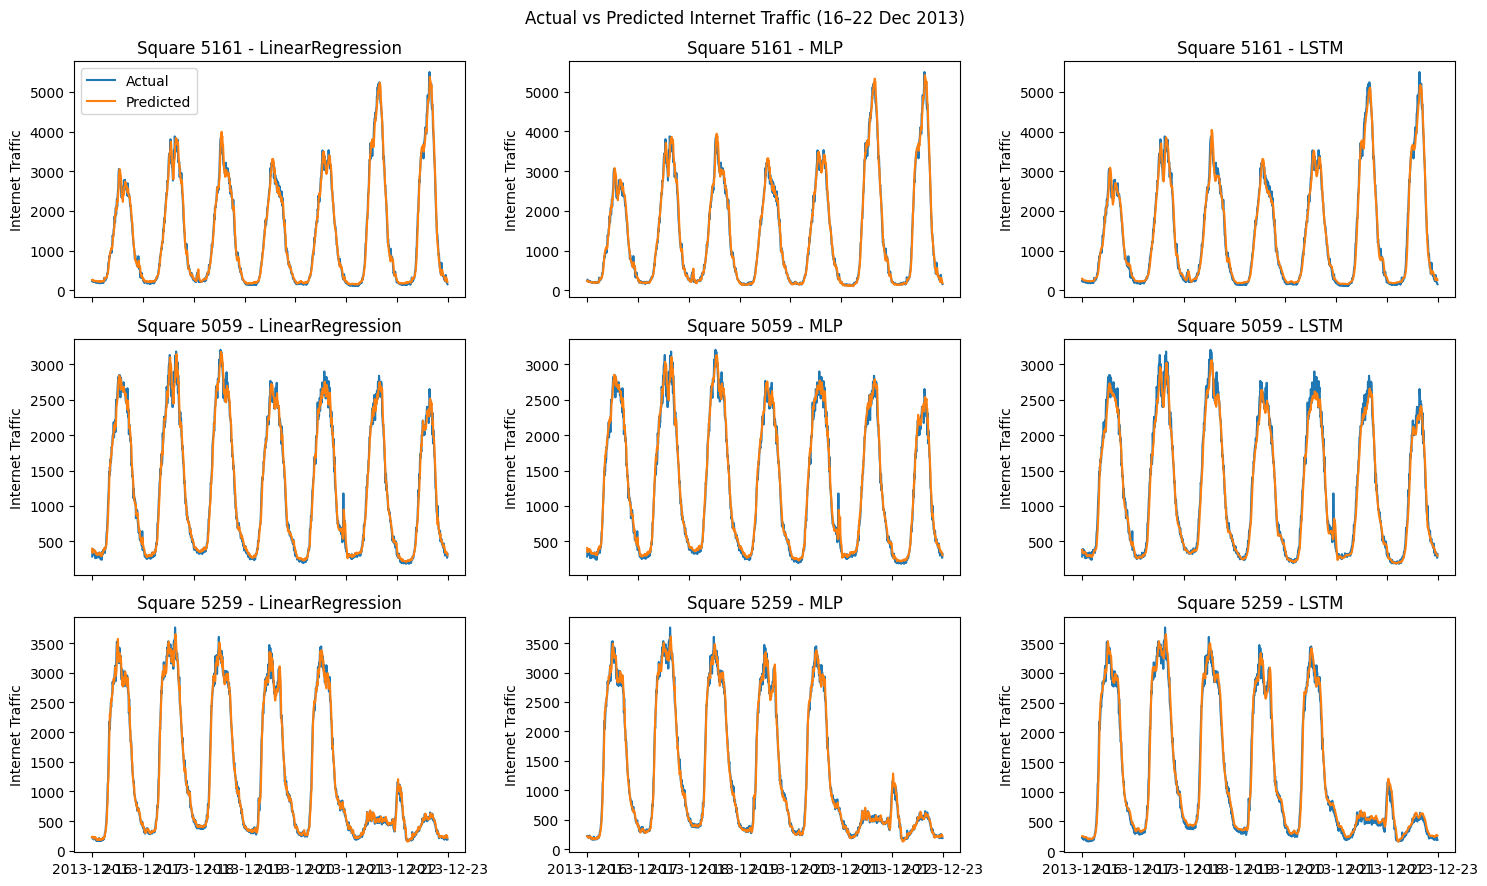

In [47]:
# Plot actual vs predicted Internet traffic
# Rows = top 3 areas
# Columns = Linear Regression, MLP, LSTM

models = [
    m for m in ["LinearRegression", "MLP", "LSTM"]
    if m in MODELS
]

fig, axes = plt.subplots(
    len(top3),
    len(models),
    figsize=(5 * len(models), 3 * len(top3)),
    sharex=True
)

axes = np.atleast_2d(axes)

for row, square in enumerate(top3):

    # Get predictions for this area
    data = predictions[square]

    for col, model in enumerate(models):

        ax = axes[row, col]

        # Actual values
        ax.plot(
            data["times"],
            data["y_true"],
            label="Actual"
        )

        # Model predictions
        ax.plot(
            data["times"],
            data["preds"][model],
            label="Predicted"
        )

        ax.set_title(f"Square {square} - {model}")
        ax.set_ylabel("Internet Traffic")

        # Show legend once
        if row == 0 and col == 0:
            ax.legend()

plt.suptitle(
    "Actual vs Predicted Internet Traffic (16–22 Dec 2013)"
)

plt.tight_layout()
plt.show()

### Interpretation of the actual-versus-predicted plots

The predictions from all three models follow the repeated daily rises and falls closely, especially during the smooth parts of each cycle. Differences become more visible at sharp peaks, sudden drops, and irregular movements. The MLP generally tracks the actual curve most closely, matching the metric tables, while the LSTM visibly misses some peaks and troughs. The same broad pattern appears across the three areas, but the lower volume Square 5259 has a changing pattern late in the week that is harder for every model.

In [48]:
# Average training and prediction time
timing_df = pd.DataFrame(timings)

avg_timing = timing_df.groupby("Model")[["Train (s)", "Predict (s)"]].mean()

print("Average time per model:")
display(avg_timing)

# Hardware and Python information
print("\nHardware / Environment:")
print("Platform :", platform.platform())
print("Processor:", platform.processor())
print("Python   :", platform.python_version())

Average time per model:


,Train (s),Predict (s)
Model,,
LSTM,6.975,0.315
LinearRegression,0.009,0.001
MLP,1.648,0.001
Persistence,0.000,0.000



Hardware / Environment:
Platform : Windows-11-10.0.26200-SP0
Processor: Intel64 Family 6 Model 154 Stepping 4, GenuineIntel
Python   : 3.13.5


### Interpretation of training and prediction time

Persistence is effectively free because it copies the last lag. Linear Regression is also very fast, averaging 0.009 seconds to train and 0.001 seconds to predict. The MLP costs more to train at 1.648 seconds on average but has nearly the same prediction time. The LSTM is substantially slower at 6.975 seconds to train and 0.315 seconds to predict, yet it has the weakest test accuracy here. Under these settings, the MLP offers the best accuracy-to-computation trade-off.

### 4.5 Failure analysis

Where do the models struggle? Zoom into one day, and look at the average error by hour of
day (does it get worse at the morning ramp or the evening peak?).

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15652\3427520208.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = start + pd.Timedelta(days=1)


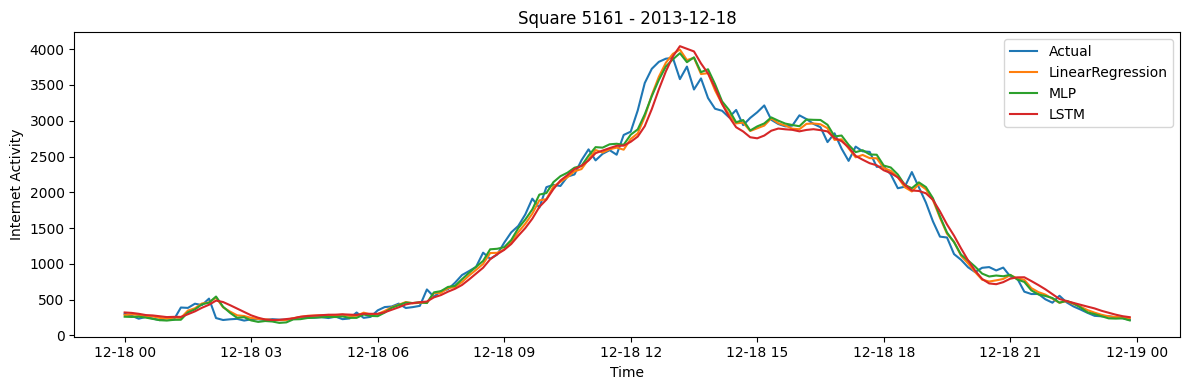

In [50]:
# Plot one day of actual vs predicted traffic
def plot_one_day(square, day="2013-12-18"):

    data = predictions[square]

    # Select only the chosen day
    start = pd.Timestamp(day)
    end = start + pd.Timedelta(days=1)

    mask = (data["times"] >= start) & (data["times"] < end)

    plt.figure(figsize=(12, 4))

    # Actual values
    plt.plot(
        data["times"][mask],
        data["y_true"][mask],
        label="Actual"
    )

    # Model predictions
    for model in model_cols:
        plt.plot(
            data["times"][mask],
            data["preds"][model][mask],
            label=model
        )

    plt.title(f"Square {square} - {day}")
    plt.xlabel("Time")
    plt.ylabel("Internet Activity")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Show one day for the highest-traffic area
model_cols = [
    model for model in ["LinearRegression", "MLP", "LSTM"]
    if model in predictions[top3[0]]["preds"]
]

plot_one_day(top3[0], "2013-12-18")

### Interpretation of the one day failure analysis

The one day  shows that the models are accurate during smooth overnight and daytime sections but lag or smooth over abrupt ramps and peaks. These are the periods where a short lag lagged data cannot fully anticipate a sudden change.

This takes the full prediction results and zooms in on one day so you can easily see where the models' predictions differ from the actual Internet traffic.

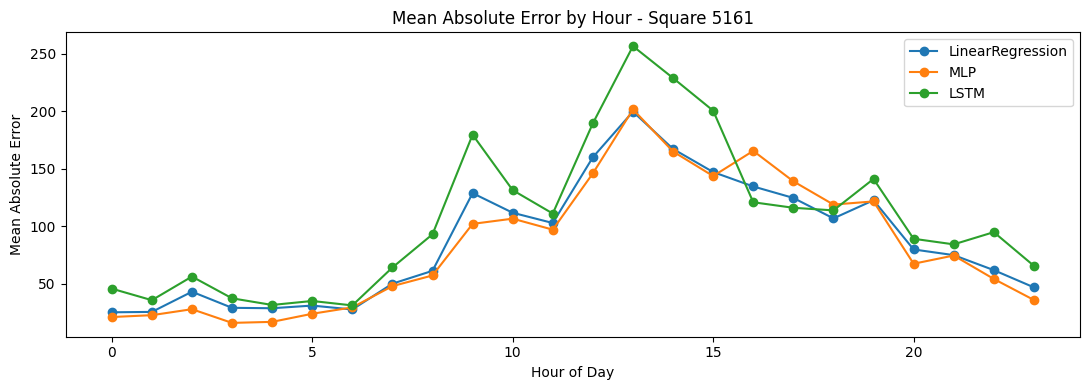

,LinearRegression,MLP,LSTM
hour,,,
0,24.982,20.867,45.559
1,25.326,22.479,35.520
2,42.875,27.684,56.074
3,28.880,15.774,37.152
4,28.516,16.662,31.375
5,30.836,23.712,34.829
6,27.434,29.243,30.975
7,49.882,47.759,63.964
8,61.059,57.029,92.840


In [51]:
# Check which hours are hardest for the models
data = predictions[top3[0]]

# Get the hour and calculate absolute error
error = pd.DataFrame({
    "hour": data["times"].hour
})

for model in model_cols:
    error[model] = np.abs(
        data["y_true"] - data["preds"][model]
    )

# Average error for each hour
hour_error = error.groupby("hour")[model_cols].mean()

# Plot the results
hour_error.plot(marker="o", figsize=(11, 4))

plt.title(f"Mean Absolute Error by Hour - Square {top3[0]}")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

# Show the exact values
display(hour_error.round(3))

### Interpretation of the hourly-error plot and table

Errors are smallest overnight and rise during the morning ramp and daytime peaks. For Square 5161, the largest displayed errors occur around 13:00: MLP is about 201.5, Linear Regression about 199.6, and LSTM about 256.5. The MLP is usually the lowest-error model through the difficult daytime period, although Linear Regression is slightly better at a few individual hours. LSTM has the highest error at most peak hours, confirming that its extra sequential capacity did not help with these short, abrupt changes.

### Discussion  4

The MLP has the lowest error in each of the three top-traffic areas, so the model ranking does not change across these examples. Its MAE is 83.252 for Square 5161, 70.466 for Square 5059, and 64.534 for Square 5259. Linear Regression is consistently competitive and beats persistence, while LSTM performs worst on the untouched test week.

This result agrees with Task 2: strong short-lag autocorrelation and a repeated daily cycle make the recent lag window informative. The MLP can learn non-linear relationships among those lags, but the LSTM does not gain an advantage from its recurrent memory with the current short input window, limited training budget, and data characteristics.

Accuracy must be weighed against execution cost. MLP training averages 1.648 seconds compared with 0.009 seconds for Linear Regression and 6.975 seconds for LSTM. Because the LSTM is both slower and less accurate here, its extra cost is not justified for this experiment. A different conclusion could require more tuning, longer sequences, additional calendar features, or a larger evaluation period.

The failure analysis shows the clearest weakness around daytime ramps and peaks. For Square 5161, average error is highest around 13:00, reaching about 201.5 for MLP and 256.5 for LSTM. These abrupt changes are difficult to infer from only the previous 12 observations, so the models smooth the peak or react after it has started. This is the main remaining limitation of the otherwise strong daily-cycle forecasts.